<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QForce001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# QFT009a: Wave Propagation Fidelity
# Act XVII: Electromagnetic Emergence
# Initialization cell

import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100              # lattice size
timesteps = 1000     # evolution steps
epsilon = 0.01       # initial amplitude
omega = 1.0          # oscillation frequency

# Initialize lattice with sinusoidal perturbation
x = np.linspace(0, 2*np.pi, N)
lattice = epsilon * np.sin(omega * x)

# Store evolution
history = [lattice.copy()]


In [2]:
# Propagation cell
# Simple update rule: wave propagation via finite difference

def evolve(lattice, c=1.0, dt=0.1):
    new = lattice.copy()
    for i in range(1, len(lattice)-1):
        new[i] = lattice[i] + c*dt*(lattice[i+1] - 2*lattice[i] + lattice[i-1])
    return new

for t in range(timesteps):
    lattice = evolve(lattice)
    if t % 50 == 0:  # record snapshots
        history.append(lattice.copy())


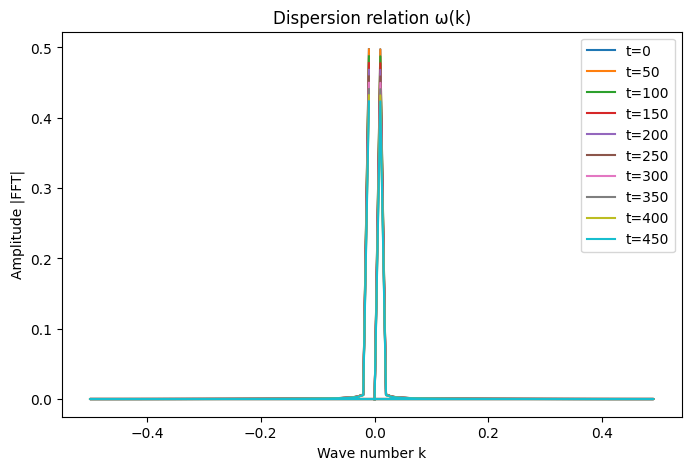

In [3]:
# Metrics cell
# Dispersion relation and phase coherence

# Fourier transform to extract k-modes
fft_modes = [np.fft.fft(h) for h in history]
k = np.fft.fftfreq(N, d=1.0)

# Dispersion plot
plt.figure(figsize=(8,5))
for idx, fft in enumerate(fft_modes[:10]):
    plt.plot(k, np.abs(fft), label=f"t={idx*50}")
plt.xlabel("Wave number k")
plt.ylabel("Amplitude |FFT|")
plt.title("Dispersion relation ω(k)")
plt.legend()
plt.show()


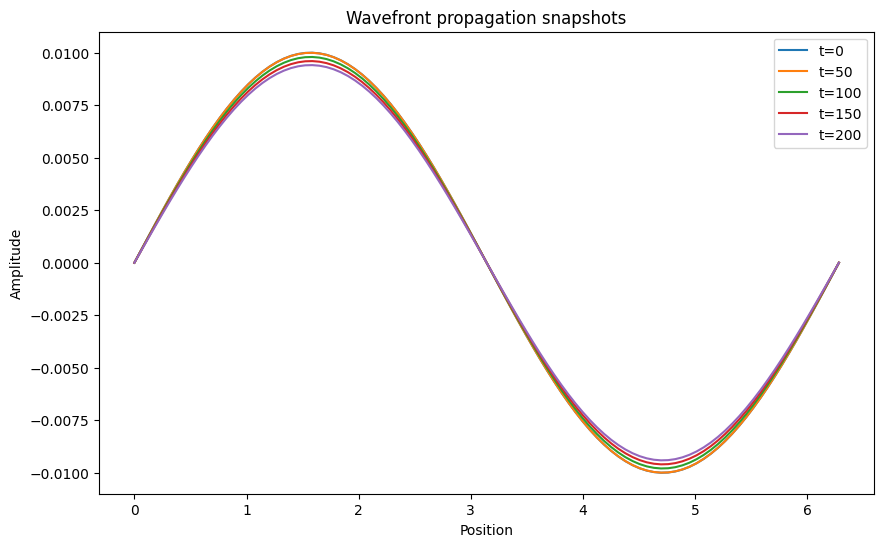

In [4]:
# Wavefront snapshots
plt.figure(figsize=(10,6))
for idx, h in enumerate(history[:5]):
    plt.plot(x, h, label=f"t={idx*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Wavefront propagation snapshots")
plt.legend()
plt.show()


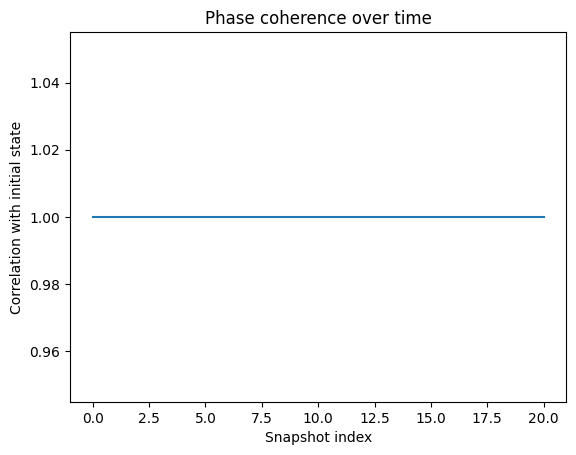

In [5]:
# Correlation metric over time
def correlation(a, b):
    return np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b))

corrs = [correlation(history[0], h) for h in history]

plt.plot(range(len(corrs)), corrs)
plt.xlabel("Snapshot index")
plt.ylabel("Correlation with initial state")
plt.title("Phase coherence over time")
plt.show()
